# Test: $|\langle JJ\rangle|$ abs estimators -- drop-Im vs complex (free massless)

We estimate $|\langle JJ\rangle|(\Delta t)$ -- the absolute value of the (jackknifed) **mean** -- with error
bars, i.e. $|\langle JJ\rangle|$, NOT $\langle|JJ|\rangle$.  Golden rule: jackknife the signed/linear mean,
then apply $|\cdot|$ to the resampled means.

Two choices for the abs of a complex per-sample estimator $C_i=\mathrm{Re}_i+i\,\mathrm{Im}_i$:
- **(A) drop Im:** $|\langle JJ\rangle|_A=\big|\,\mathrm{Re}\langle C\rangle\,\big|$  (use the real channel only).
- **(B) complex:** $|\langle JJ\rangle|_B=\big|\langle C\rangle\big|=\sqrt{\mathrm{Re}\langle C\rangle^2+\mathrm{Im}\langle C\rangle^2}$.

We established the gauge-averaged $\mathrm{Im}\langle JJ\rangle=0$ exactly (so Im is pure noise).  Expectation:
A and B agree in the **signal** region; in the **noise floor** B is biased HIGHER (it adds the Im noise
floor), so **A is preferred**.  We also show the bias-subtracted A,
$\widehat{|G|}=\sqrt{\max(0,\bar r^2-\sigma^2)}$ (see `jj_abs_estimator_claude.md`), and the Im mean as a
noise gauge.  Test object = the connected tp / sp `Vpp` (the channel with Re-signal / Im-noise).  Data =
the SAME free massless ensemble as `jj_corr_massless_claude.ipynb` (resample over hits).

In [1]:
import h5py, glob, math
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted

In [2]:
# ---- parameters: same free massless ensemble as jj_corr_massless_claude.ipynb ----
dir1  = '/mnt/barracuda22/qed3/qed3/src/both_3d/'
ens   = 'free'
mre, mim = 0.0, 0.0
n_t0, nhits, Nt = 2, 64, 128
at = 0.200000
binsize = 1
esnid = ens + '_vmRe%.6fvmIm%.6f' % (mre, mim)
cdir  = dir1 + 'data_' + esnid + '/corr_nt0%d_nhits%d/' % (n_t0, nhits)
xxx   = at * np.arange(Nt)
print('corr dir =', cdir)

corr dir = /mnt/barracuda22/qed3/qed3/src/both_3d/data_free_vmRe0.000000vmIm0.000000/corr_nt02_nhits64/


In [3]:
# ---- loader: per-HIT complex samples (avg over t0 within a hit; free field => hits are the ensemble) ----
def load_conn(leaf):
    '''Return (nhits, Nt) complex: connected leaf (e.g. "tp/Vpp"), one row per hit (t0-averaged).'''
    samp = []
    for fn in natsorted(glob.glob(cdir + 'corr.*.h5')):
        with h5py.File(fn, 'r') as f:
            if 'complete' not in f: continue
            for hk in natsorted(k for k in f.keys() if k.startswith('h') and k[1:].isdigit()):
                tks = natsorted(t for t in f[hk].keys() if t.startswith('t0_'))
                a = [f['%s/%s/%s/real'%(hk,tk,leaf)][:] + 1j*f['%s/%s/%s/imag'%(hk,tk,leaf)][:]
                     for tk in tks if '%s/%s/%s/real'%(hk,tk,leaf) in f]
                if a: samp.append(np.mean(a, axis=0))
    return np.array(samp)

In [4]:
# ---- jackknife of |<JJ>| = func(mean): central = func(full mean), error = leave-one-out ----
def jk_func(samples, func):
    '''samples (nsamp,Nt) real/complex; func maps a length-Nt mean -> length-Nt real. Returns (central, err).'''
    n = samples.shape[0] // binsize
    full = func(samples.mean(0))
    jk = np.empty((n, samples.shape[1]))
    for b in range(n):
        red = np.delete(samples, np.s_[b*binsize:(b+1)*binsize], axis=0)
        jk[b] = func(red.mean(0))
    m = jk.mean(0)
    err = np.sqrt((n - 1) / n * np.sum((jk - m)**2, axis=0))
    return full, err

# strategies (func of the complex mean c):
absA = lambda c: np.abs(c.real)        # (A) drop Im
absB = lambda c: np.abs(c)             # (B) complex |.|
reMean = lambda c: c.real              # signed Re (for floor / debias)
imMean = lambda c: c.imag              # Im mean (noise gauge; expect ~0)

In [5]:
# ---- compute all estimators for one projection ----
def estimators(leaf):
    C = load_conn(leaf)                       # (nhits, Nt) complex
    gA, eA = jk_func(C, absA)                 # |<JJ>|_A  (drop Im)
    gB, eB = jk_func(C, absB)                 # |<JJ>|_B  (complex)
    gR, eR = jk_func(C, reMean)               # signed Re mean +/- err
    gI, eI = jk_func(C, imMean)               # Im mean (gauge)
    gAdb   = np.sqrt(np.maximum(0.0, gR**2 - eR**2))   # bias-subtracted A
    floor  = np.abs(gR) < 2*eR                # noise-floor mask (signal/err < 2)
    return dict(C=C, gA=gA, eA=eA, gB=gB, eB=eB, gR=gR, eR=eR, gI=gI, eI=eI, gAdb=gAdb, floor=floor)

tp = estimators('tp/Vpp')
sp = estimators('sp/Vpp')
print('tp nhits x Nt =', tp['C'].shape, '  sp =', sp['C'].shape)

tp nhits x Nt = (64, 128)   sp = (64, 128)


## A vs B (and bias-subtracted A) on a log axis

Expect: in the signal region all three coincide; in the floor (open markers) **B sits above A** (extra Im
noise), and the bias-subtracted A drops toward zero / upper-limit.

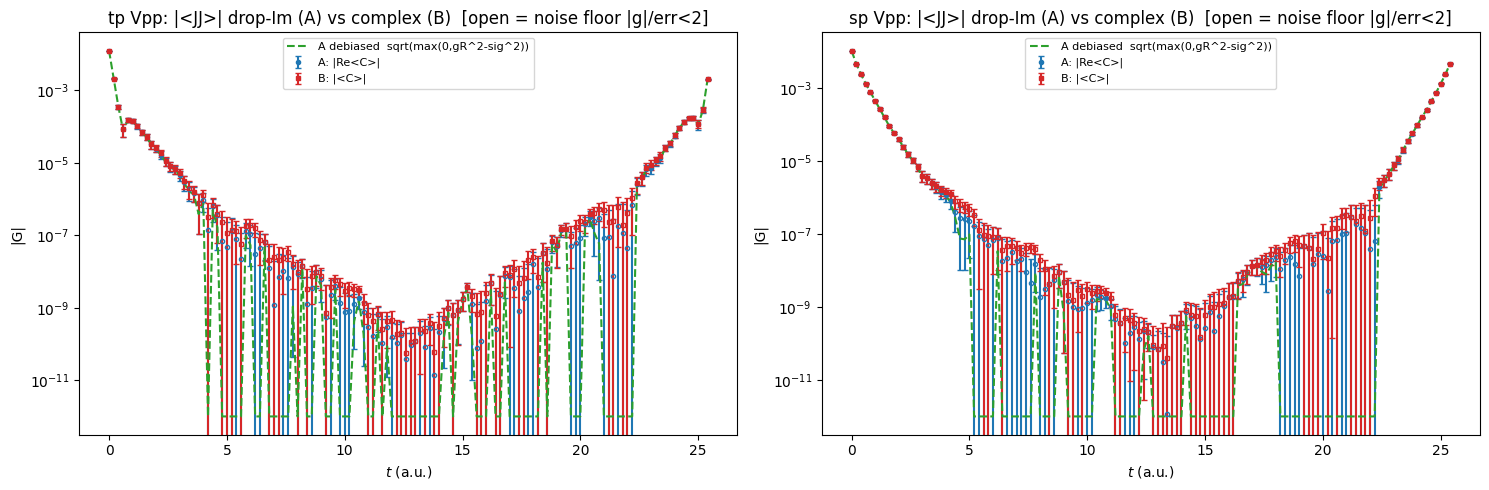

In [6]:
def plot_AB(d, name, ax):
    sig = ~d['floor']; flo = d['floor']
    # A (drop Im)
    ax.errorbar(xxx[sig], d['gA'][sig], d['eA'][sig], fmt='o', ms=3, capsize=2, color='C0', label='A: |Re<C>|')
    ax.errorbar(xxx[flo], d['gA'][flo], d['eA'][flo], fmt='o', ms=3, capsize=2, color='C0', mfc='none')
    # B (complex)
    ax.errorbar(xxx[sig], d['gB'][sig], d['eB'][sig], fmt='s', ms=3, capsize=2, color='C3', label='B: |<C>|')
    ax.errorbar(xxx[flo], d['gB'][flo], d['eB'][flo], fmt='s', ms=3, capsize=2, color='C3', mfc='none')
    # bias-subtracted A
    ax.plot(xxx, np.maximum(d['gAdb'], 1e-12), '--', color='C2', label='A debiased  sqrt(max(0,gR^2-sig^2))')
    ax.set_yscale('log'); ax.set_xlabel('$t$ (a.u.)'); ax.set_ylabel('|G|'); ax.legend(fontsize=8)
    ax.set_title('%s: |<JJ>| drop-Im (A) vs complex (B)  [open = noise floor |g|/err<2]' % name)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_AB(tp, 'tp Vpp', ax[0]); plot_AB(sp, 'sp Vpp', ax[1])
plt.tight_layout()

## Noise gauge: the Im mean (must be $\approx 0$) and where B's excess comes from

$\langle\mathrm{Im}\rangle$ is signal-free (exactly zero in expectation); its scatter sets the floor and is
exactly the excess that B picks up over A.  Plot $|\mathrm{Re}\langle C\rangle|$ and $|\mathrm{Im}\langle
C\rangle|$ together: where they cross, B starts to be dominated by Im noise.

tp: median |B-A|/A in floor = 0.657 , in signal = 0.018
sp: median |B-A|/A in floor = 0.498 , in signal = 0.002


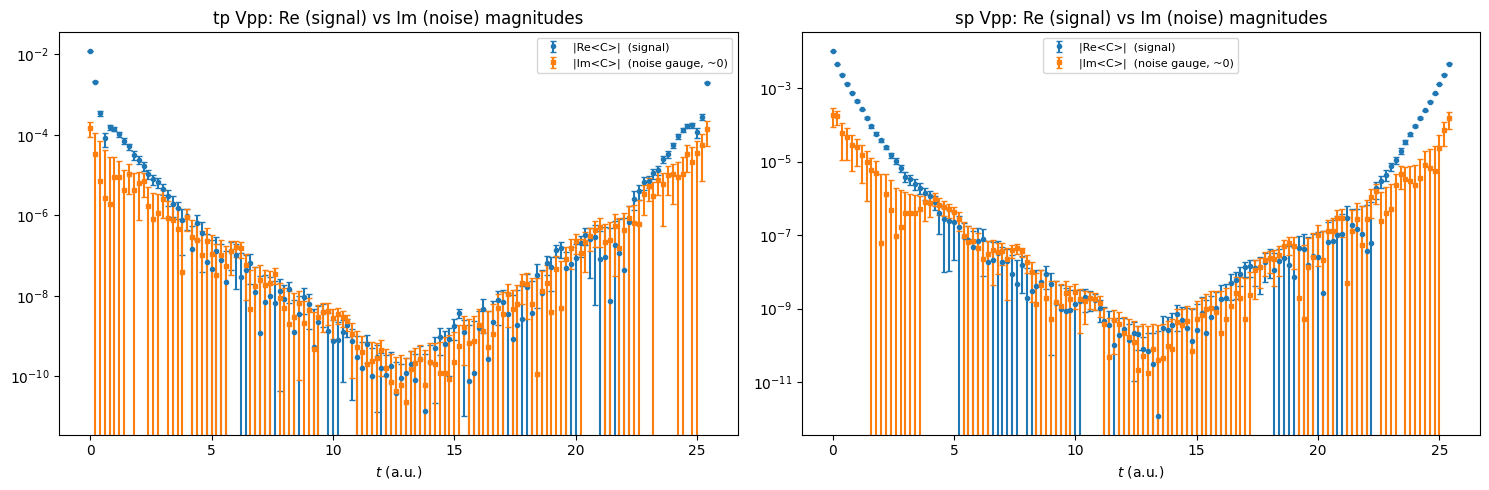

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
for a, d, name in [(ax[0], tp, 'tp Vpp'), (ax[1], sp, 'sp Vpp')]:
    a.errorbar(xxx, np.abs(d['gR']), d['eR'], fmt='o', ms=3, capsize=2, color='C0', label='|Re<C>|  (signal)')
    a.errorbar(xxx, np.abs(d['gI']), d['eI'], fmt='s', ms=3, capsize=2, color='C1', label='|Im<C>|  (noise gauge, ~0)')
    a.set_yscale('log'); a.set_xlabel('$t$ (a.u.)'); a.legend(fontsize=8)
    a.set_title('%s: Re (signal) vs Im (noise) magnitudes' % name)
plt.tight_layout()
# quantify: fractional excess of B over A
for d, name in [(tp,'tp'),(sp,'sp')]:
    exc = (d['gB'] - d['gA']) / np.maximum(np.abs(d['gA']), 1e-300)
    print('%s: median |B-A|/A in floor = %.3f , in signal = %.3f'
          % (name, np.median(exc[d['floor']]) if d['floor'].any() else float('nan'),
                   np.median(exc[~d['floor']]) if (~d['floor']).any() else float('nan')))

## Takeaway

- **Signal region:** A and B agree (Im negligible) -> either is fine.
- **Noise floor:** B $>$ A by the Im noise it adds; A (drop Im) has the smaller upward bias, and the
  **bias-subtracted A** removes the floor bias of A itself.  => prefer **A (drop Im)**, debiased, with the
  floor points reported as upper limits.
- The Im-mean panel confirms $\langle\mathrm{Im}\rangle\approx0$ (consistency) and shows the crossover where
  the correlator sinks into the noise.